<a href="https://colab.research.google.com/github/Gurshaanbirsinghgill/Python-Project-on-IPL/blob/main/Python_Project_by_Aishpreet_%2C_Jashan_and_Shaan_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

#Load CSV
df = pd.read_csv("ipl_2025_deliveries csv file .csv")

# Preview data
print(df.head())
print(df.info())
print(df.isnull().sum())

#Remove Duplicates
df = df.drop_duplicates()

#Fix Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

#Filling null values
df.fillna(0 , inplace=True)


   match_id  season        phase  match_no          date  \
0    202501    2025  Group Stage         1  Mar 22, 2025   
1    202501    2025  Group Stage         1  Mar 22, 2025   
2    202501    2025  Group Stage         1  Mar 22, 2025   
3    202501    2025  Group Stage         1  Mar 22, 2025   
4    202501    2025  Group Stage         1  Mar 22, 2025   

                   venue batting_team bowling_team  innings  over  ...  \
0  Eden Gardens, Kolkata          KKR          RCB        1   0.1  ...   
1  Eden Gardens, Kolkata          KKR          RCB        1   0.2  ...   
2  Eden Gardens, Kolkata          KKR          RCB        1   0.3  ...   
3  Eden Gardens, Kolkata          KKR          RCB        1   0.4  ...   
4  Eden Gardens, Kolkata          KKR          RCB        1   0.5  ...   

      bowler runs_of_bat  extras  wide  legbyes  byes  noballs  wicket_type  \
0  Hazlewood           0       0     0        0     0        0          NaN   
1  Hazlewood           4       0    

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ipl_2025_deliveries csv file .csv")

df.head()

#Basic cleaning data
# Check columns
print(df.columns)

# Fill missing values
df.fillna(0, inplace=True)

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

#Create new column
# Total runs per ball
df['total_runs'] = df['runs_of_bat'] + df['extras']

Index(['match_id', 'season', 'phase', 'match_no', 'date', 'venue',
       'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler',
       'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs',
       'wicket_type', 'player_dismissed', 'fielder'],
      dtype='object')


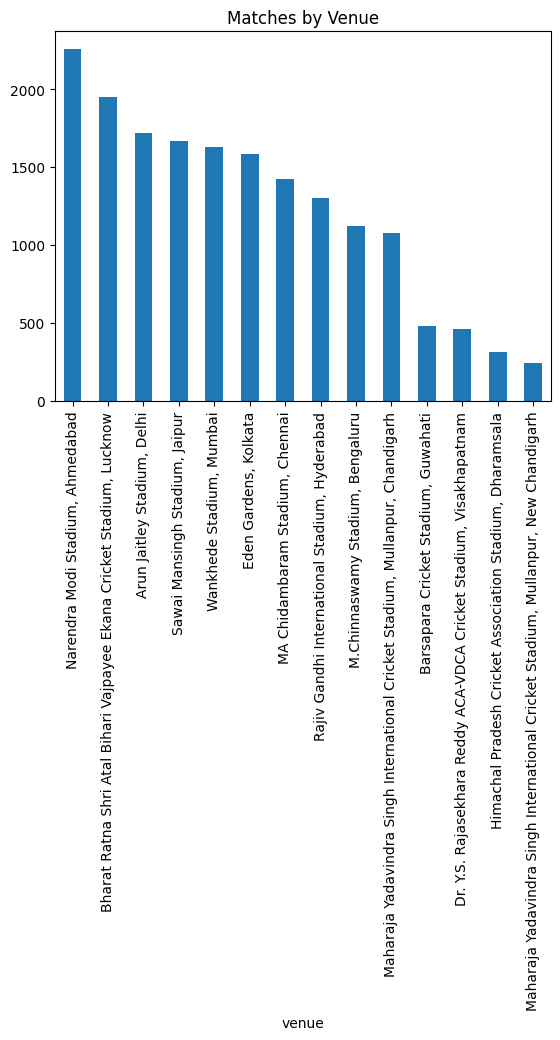

In [ ]:
#Creating Charts - Match By Venue
df['venue'].value_counts().plot(kind='bar')
plt.title("Matches by Venue")
plt.show()

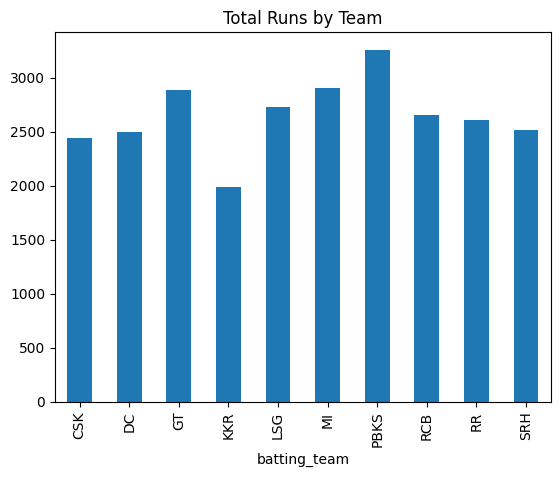

In [ ]:
#2 Runs by Batting Team
df.groupby('batting_team')['total_runs'].sum().plot(kind='bar')
plt.title("Total Runs by Team")
plt.show()

In [ ]:
#3 Wickets by Bowling Team
df['wicket_type'] = df['wicket_type'].replace(0, None)

df.dropna(subset=['wicket_type']).groupby('bowling_team')['wicket_type'].count().plot(kind='bar')
plt.title("Wickets by Team")
plt.show()

NameError: name 'df' is not defined

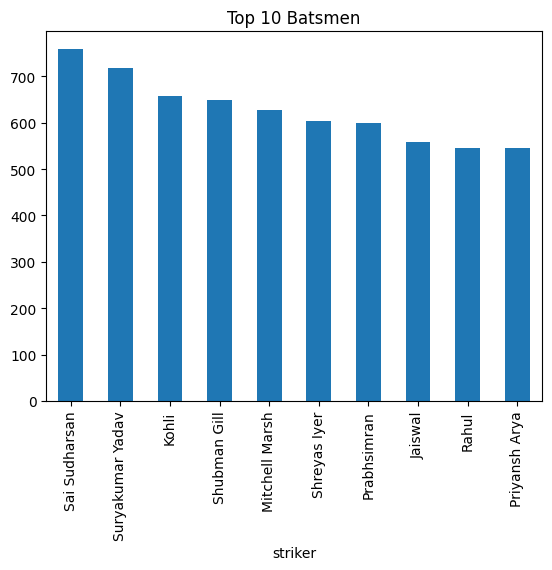

In [ ]:
#4 Top Batsmen
df.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Batsmen")
plt.show()

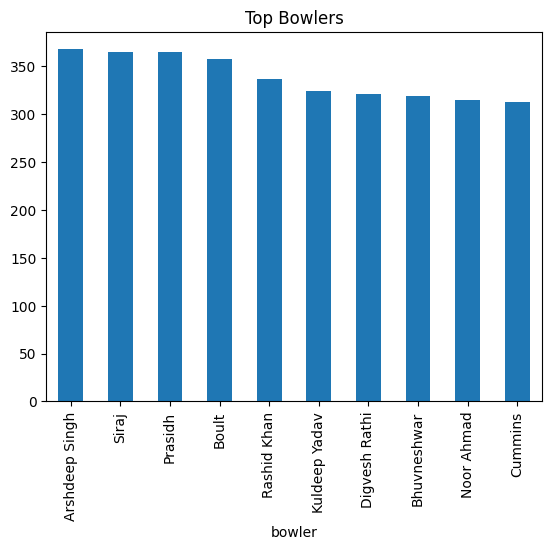

In [ ]:
#5 Top Bowlers (Wickets)
df.dropna(subset=['player_dismissed']).groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Bowlers")
plt.show()

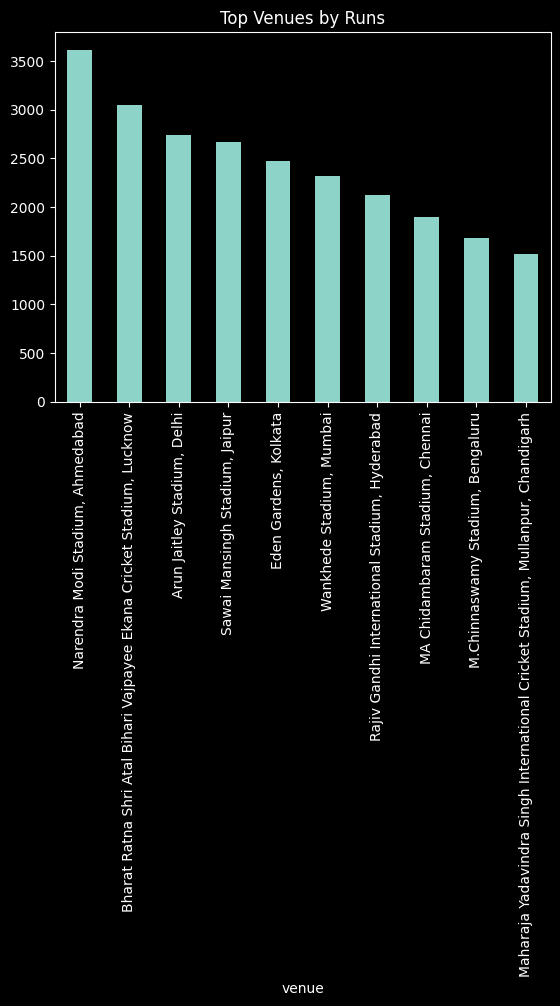

In [ ]:
#6 Runs Distribution
df.groupby('venue')['total_runs'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Venues by Runs")
plt.show()

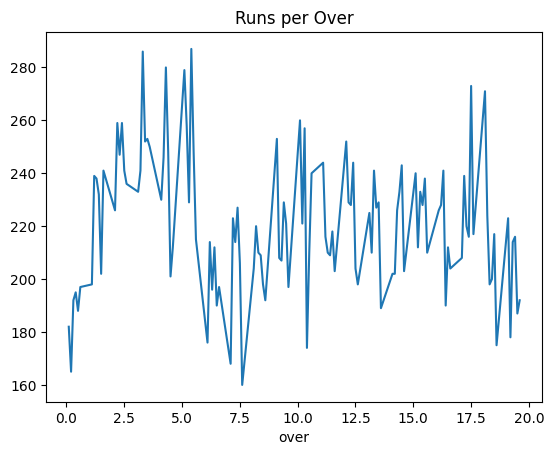

In [ ]:
#7 Runs Per Over
df.groupby('over')['total_runs'].sum().plot()
plt.title("Runs per Over")
plt.show()

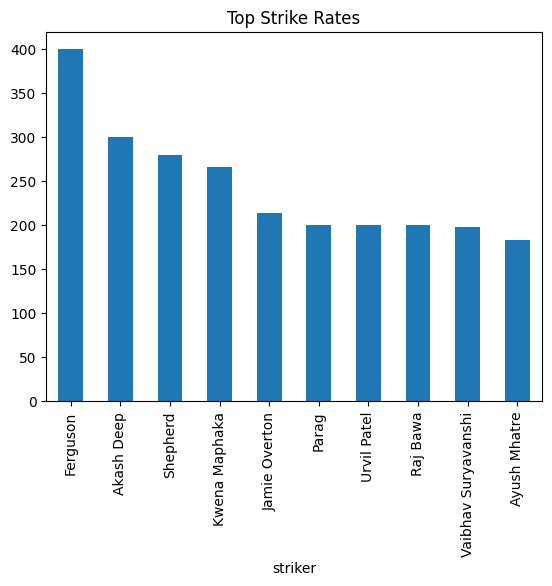

In [ ]:
#8 Strike Rate of Players
runs = df.groupby('striker')['runs_of_bat'].sum()
balls = df.groupby('striker').size()

strike_rate = (runs / balls) * 100

strike_rate.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Strike Rates")
plt.show()

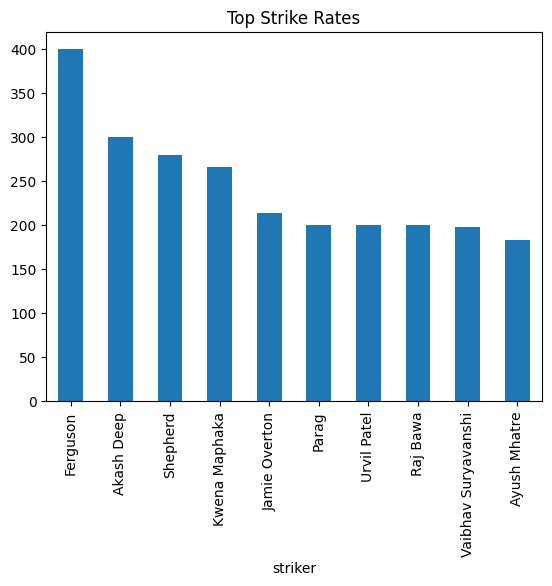

In [ ]:
#9 Extras Distribution
runs = df.groupby('striker')['runs_of_bat'].sum()
balls = df.groupby('striker').size()

strike_rate = (runs / balls) * 100

strike_rate.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Strike Rates")
plt.show()

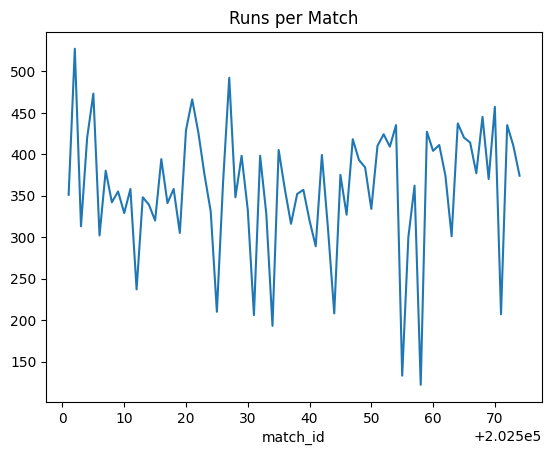

In [ ]:
#10 Runs by Match
df.groupby('match_id')['total_runs'].sum().plot()
plt.title("Runs per Match")
plt.show()

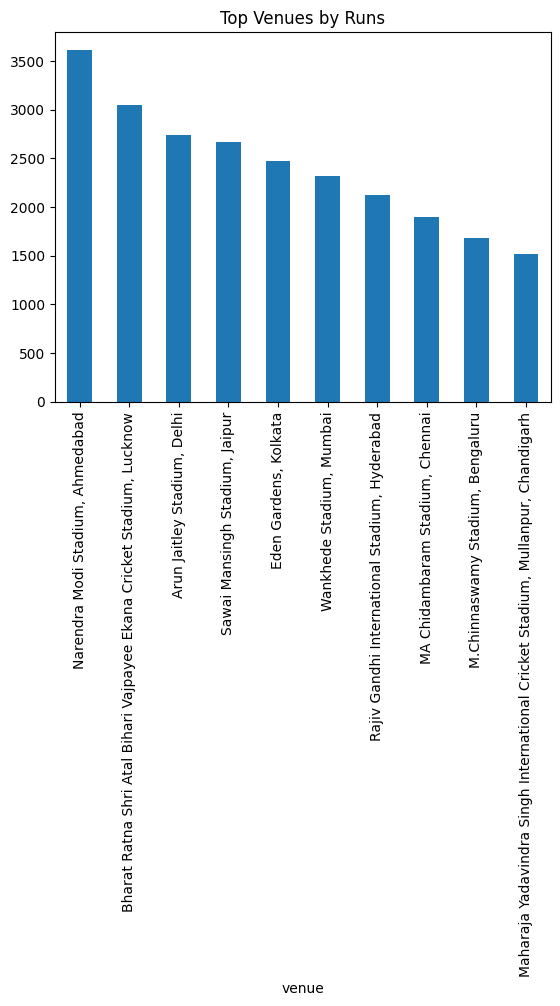

In [ ]:
#11 Top Venues by Runs
df.groupby('venue')['total_runs'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Venues by Runs")
plt.show()

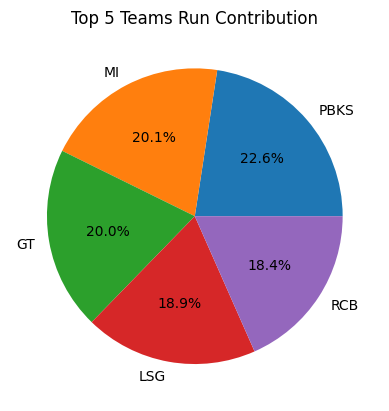

In [ ]:
#12 Run Contribution By Top Teams
top_teams = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(5)

top_teams.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Teams Run Contribution")
plt.ylabel("")
plt.show()

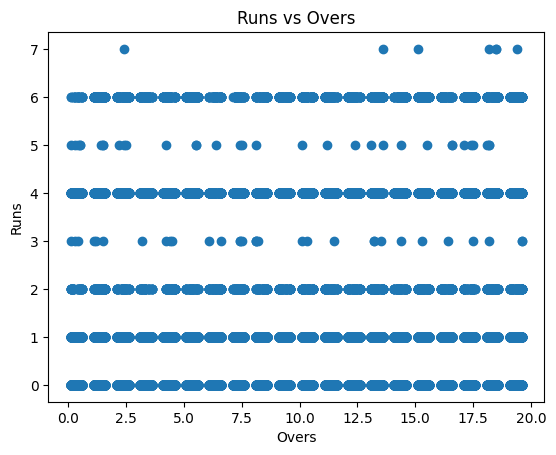

In [ ]:
#13 Runs vs Overs
plt.scatter(df['over'], df['total_runs'])
plt.title("Runs vs Overs")
plt.xlabel("Overs")
plt.ylabel("Runs")
plt.show()

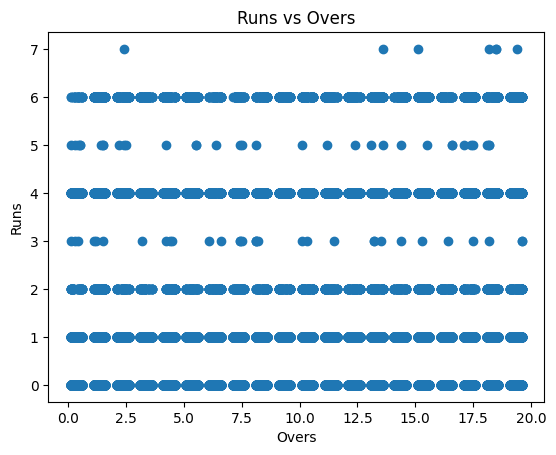

In [ ]:
#14 Ball Number vs Runs
plt.scatter(df['over'], df['total_runs'])
plt.title("Runs vs Overs")
plt.xlabel("Overs")
plt.ylabel("Runs")
plt.show()

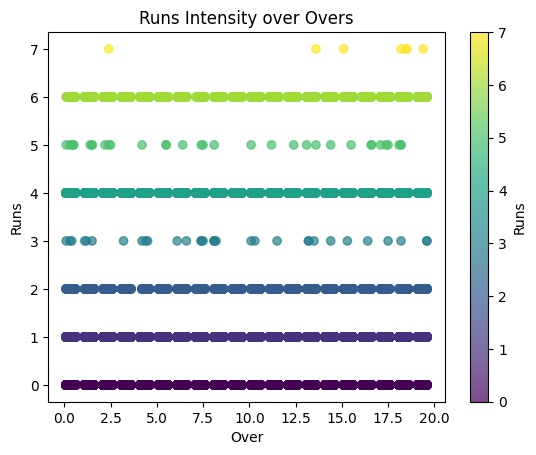

In [ ]:
#15 Runs Intensity
plt.scatter(df['over'], df['total_runs'],
            c=df['total_runs'], cmap='viridis', alpha=0.7)

plt.colorbar(label='Runs')
plt.title("Runs Intensity over Overs")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

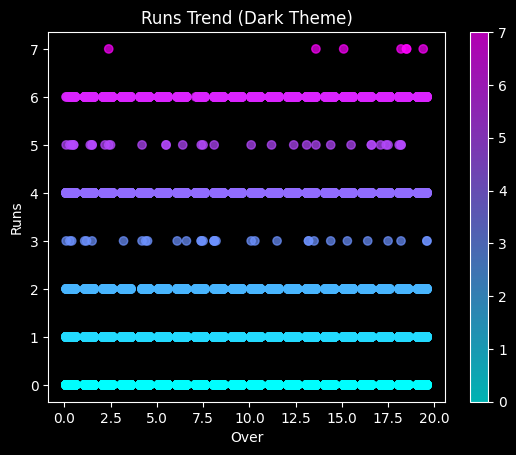

In [ ]:
#16
plt.style.use('dark_background')

plt.scatter(df['over'], df['total_runs'],
            c=df['total_runs'], cmap='cool', alpha=0.7)

plt.colorbar()
plt.title("Runs Trend (Dark Theme)")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

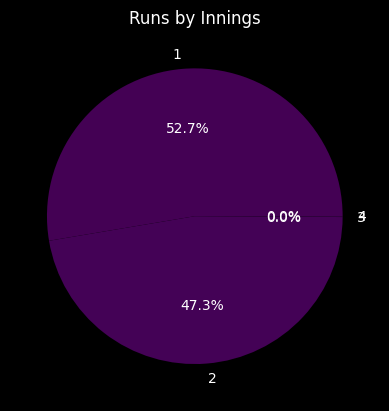

In [ ]:
#17 Total Runs
data = df.groupby('innings')['total_runs'].sum()

plt.pie(data, labels=data.index, autopct='%1.1f%%',
        colors=plt.cm.viridis(range(len(data))))

plt.title("Runs by Innings")
plt.show()

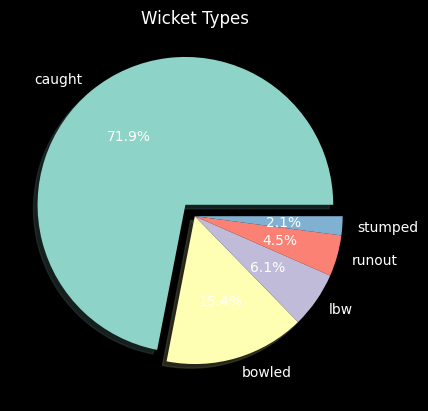

In [ ]:
#18 Wicket Types
data = df['wicket_type'].value_counts().head(5)

explode = [0.1, 0, 0, 0, 0]  # highlight first part

plt.pie(data, labels=data.index, autopct='%1.1f%%',
        explode=explode, shadow=True)

plt.title("Wicket Types")
plt.show()

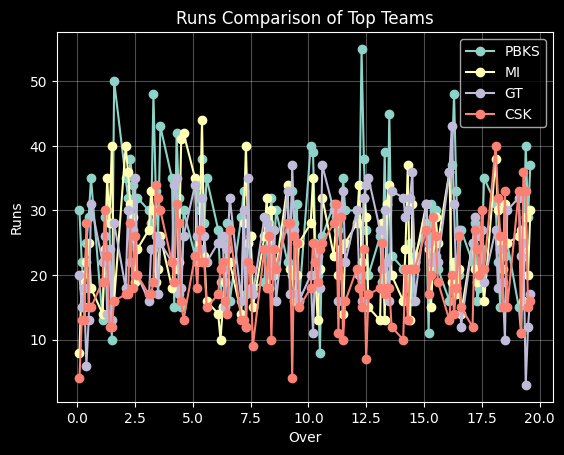

In [ ]:
#19 Top Team Comparison
top_teams = df['batting_team'].value_counts().head(4).index

for team in top_teams:
    team_df = df[df['batting_team'] == team]
    runs = team_df.groupby('over')['total_runs'].sum()
    plt.plot(runs, marker='o', label=team)

plt.legend()
plt.title("Runs Comparison of Top Teams")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.grid(alpha=0.3)
plt.show()

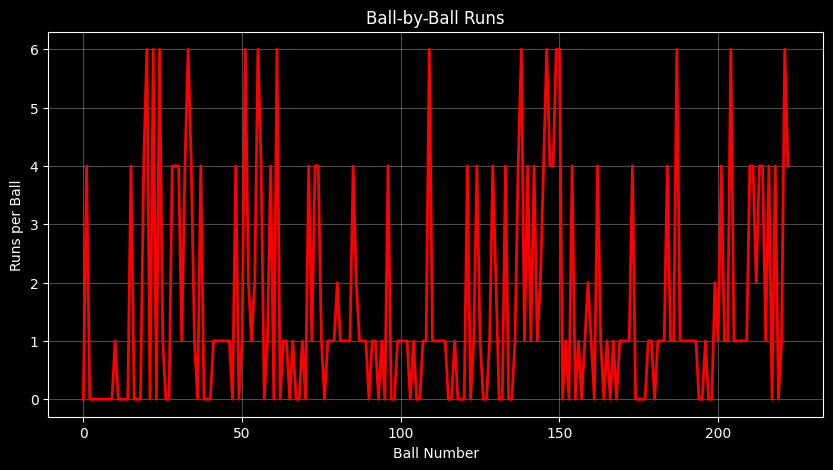

In [ ]:
#20 Ball by ball Runs
plt.figure(figsize=(10,5))

# Take one match for clean graph
match_id = df['match_id'].iloc[0]
match_df = df[df['match_id'] == match_id]

# Create ball sequence
match_df = match_df.reset_index(drop=True)

plt.plot(match_df.index, match_df['total_runs'],
         color='red', linewidth=2)

plt.title("Ball-by-Ball Runs")
plt.xlabel("Ball Number")
plt.ylabel("Runs per Ball")

plt.grid(alpha=0.3)
plt.show()